# Task 13: Neural Networks & Computer Vision

## Introduction to Deep Learning

Deep Learning is a subset of machine learning that uses artificial neural networks with multiple layers (deep neural networks) to learn representations of data. It has revolutionized computer vision, natural language processing, and speech recognition.

## 1. Understanding Neural Network, Neurons & Perceptron

### Perceptron: The Building Block

A perceptron is the simplest form of a neural network - a single neuron that makes decisions by weighing input evidence. It takes multiple inputs, applies weights, adds them up, and passes through an activation function.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Simple Perceptron Implementation
class Perceptron:
    """Single Layer Perceptron"""
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self._activation(linear_output)

                update = self.learning_rate * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

    def _activation(self, x):
        return np.where(x >= 0, 1, 0)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._activation(linear_output)

# Test Perceptron
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,
                          n_informative=2, n_clusters_per_class=1, random_state=42)
perceptron = Perceptron(learning_rate=0.1)
perceptron.fit(X, y)
y_pred = perceptron.predict(X)

print("=== Perceptron ===")
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
print(f"Weights: {perceptron.weights}")
print(f"Bias: {perceptron.bias}")

=== Perceptron ===
Accuracy: 1.0000
Weights: [-0.12020481  0.32565933]
Bias: 0.2


## 2. Neural Networks Fundamentals

A neural network consists of:
- **Input Layer**: Receives input data
- **Hidden Layers**: Process information through weighted connections
- **Output Layer**: Produces the final prediction
- **Activation Functions**: Introduce non-linearity (Sigmoid, ReLU, Tanh)

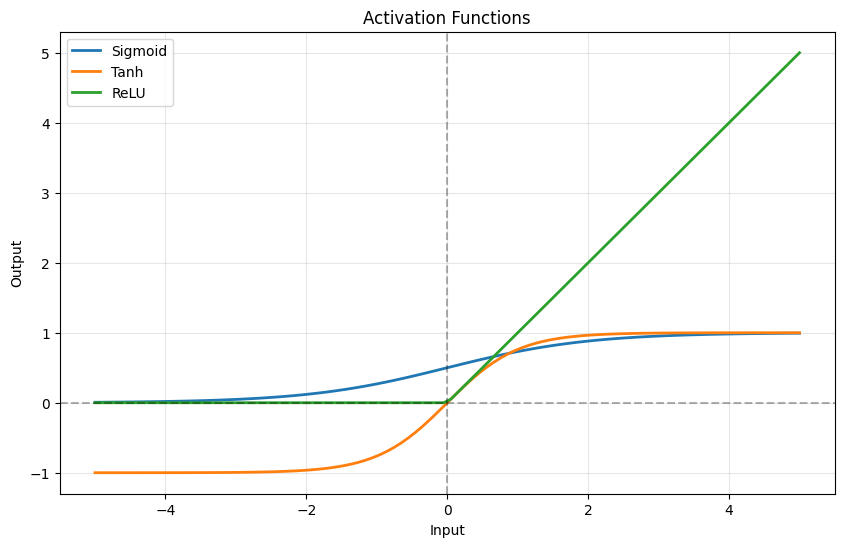

In [11]:
# Visualize Activation Functions
x = np.linspace(-5, 5, 100)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label='Sigmoid', linewidth=2)
plt.plot(x, tanh, label='Tanh', linewidth=2)
plt.plot(x, relu, label='ReLU', linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Backpropagation (From Scratch)

Backpropagation is the algorithm used to train neural networks. It computes the gradient of the loss function with respect to the network weights by propagating error backwards through the network.

In [12]:
class NeuralNetworkFromScratch:
    """
    Neural Network with Backpropagation from scratch
    """

    def __init__(self, layers, learning_rate=0.01):
        self.layers = layers
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []
        self._initialize_parameters()

    def _initialize_parameters(self):
        np.random.seed(42)
        for i in range(len(self.layers) - 1):
            w = np.random.randn(self.layers[i], self.layers[i+1]) * np.sqrt(2.0 / self.layers[i])
            b = np.zeros((1, self.layers[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _sigmoid_derivative(self, a):
        return a * (1 - a)

    def _relu(self, z):
        return np.maximum(0, z)

    def _relu_derivative(self, a):
        return (a > 0).astype(float)

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _forward(self, X):
        self.activations = [X]
        self.z_values = []

        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)

            if i < len(self.weights) - 1:
                a = self._relu(z)
            else:
                a = self._sigmoid(z)
            self.activations.append(a)

        return self.activations[-1]

    def _backward(self, X, y):
        m = X.shape[0]
        deltas = []

        # Output layer delta
        output_error = y - self.activations[-1]
        output_delta = output_error * self._sigmoid_derivative(self.activations[-1])
        deltas.insert(0, output_delta)

        # Hidden layers deltas
        for i in range(len(self.weights) - 2, -1, -1):
            error = deltas[0].dot(self.weights[i+1].T)
            delta = error * self._relu_derivative(self.activations[i+1])
            deltas.insert(0, delta)

        # Update weights and biases
        for i in range(len(self.weights)):
            self.weights[i] += self.activations[i].T.dot(deltas[i]) / m * self.learning_rate
            self.biases[i] += np.sum(deltas[i], axis=0, keepdims=True) / m * self.learning_rate

    def fit(self, X, y, epochs=1000):
        self.loss_history = []

        for epoch in range(epochs):
            output = self._forward(X)
            self._backward(X, y.reshape(-1, 1))

            if epoch % 100 == 0:
                loss = np.mean((y - output.flatten()) ** 2)
                self.loss_history.append(loss)

        return self

    def predict(self, X):
        output = self._forward(X)
        return (output.flatten() > 0.5).astype(int)

## 4. Build a Simple Feedforward Neural Network (from Scratch)

In [13]:
# Generate sample data
X, y = make_classification(n_samples=200, n_features=4, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train neural network
nn = NeuralNetworkFromScratch(layers=[4, 8, 4, 1], learning_rate=0.1)
nn.fit(X_train_scaled, y_train, epochs=500)
y_pred = nn.predict(X_test_scaled)

print("=== Neural Network (From Scratch) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

=== Neural Network (From Scratch) ===
Accuracy: 0.8750


## 5. Using Scikit-Learn MLPClassifier

In [14]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(8, 4), activation='relu',
                    solver='adam', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("=== MLP Classifier (Scikit-Learn) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")

=== MLP Classifier (Scikit-Learn) ===
Accuracy: 0.9250


## 6. Data Preprocessing & Feature Engineering with Neural Networks

In [15]:
# Image preprocessing concepts
print("Data Preprocessing for Images:")
print("1. Resize images to consistent dimensions")
print("2. Normalize pixel values (0-255 to 0-1)")
print("3. Data augmentation (rotation, flip, zoom)")
print("4. Mean subtraction and standardization")
print("5. One-hot encoding for labels")

Data Preprocessing for Images:
1. Resize images to consistent dimensions
2. Normalize pixel values (0-255 to 0-1)
3. Data augmentation (rotation, flip, zoom)
4. Mean subtraction and standardization
5. One-hot encoding for labels


## 7. Computer Vision with TensorFlow/Keras

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 8. Understanding Convolutional & Pooling Layers

### Convolutional Layers
- Apply filters/kernels to detect features (edges, textures, patterns)
- Preserve spatial relationships
- Reduce parameters compared to fully connected layers

### Pooling Layers
- Reduce spatial dimensions
- Provide translation invariance
- MaxPooling: Takes maximum value in each window
- AveragePooling: Takes average value in each window

## 9. MNIST Handwritten Digit Recognition (CNN)

## Short Assignment: Handwritten Digit Recognition (MNIST) using ANN

### Building ANN Architecture with Keras/TensorFlow for Image Classification

In [17]:
# ==========================================
# SHORT ASSIGNMENT: MNIST Digit Recognition
# Building ANN (Artificial Neural Network)
# ==========================================

# Load MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten images (784 features for 28x28 images)
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype('float32') / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training samples: {X_train_flat.shape[0]}")
print(f"Test samples: {X_test_flat.shape[0]}")
print(f"Input features (flattened): {X_train_flat.shape[1]}")
print(f"Number of classes: {10}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000
Input features (flattened): 784
Number of classes: 10


### Build ANN Architecture

In [18]:
# Build ANN (Fully Connected) Model
ann_model = models.Sequential([
    # Input layer is implicit, specify input_shape in first layer
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Output layer with softmax for multi-class classification
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

print("=== ANN Architecture for MNIST ===")
ann_model.summary()

=== ANN Architecture for MNIST ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

### Train ANN Model

In [19]:
# Train the ANN model
ann_history = ann_model.fit(X_train_flat, y_train_cat,
                             epochs=20,
                             batch_size=128,
                             validation_split=0.1,
                             verbose=1)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8659 - loss: 0.4447 - val_accuracy: 0.9645 - val_loss: 0.1208
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9422 - loss: 0.1939 - val_accuracy: 0.9677 - val_loss: 0.1069
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9537 - loss: 0.1537 - val_accuracy: 0.9718 - val_loss: 0.0921
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9611 - loss: 0.1285 - val_accuracy: 0.9775 - val_loss: 0.0791
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9661 - loss: 0.1103 - val_accuracy: 0.9797 - val_loss: 0.0687
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9688 - loss: 0.1013 - val_accuracy: 0.9840 - val_loss: 0.0597
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9728 - loss: 0.0888 - val_accuracy: 0.9812 - val_loss: 0.0616
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9739 - loss: 0.0823 - val_ac

### Evaluate ANN Model

In [20]:
# Evaluate on test set
test_loss, test_acc = ann_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"\n=== ANN Model Evaluation (MNIST) ===")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")


=== ANN Model Evaluation (MNIST) ===
Test Accuracy: 0.9824 (98.24%)
Test Loss: 0.0595


### Visualize ANN Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


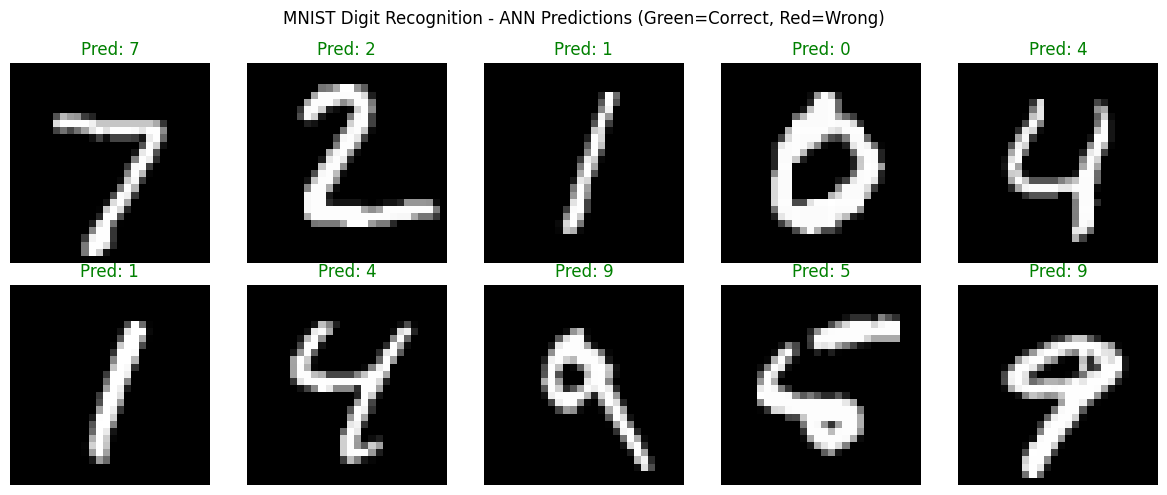

In [21]:
# Make predictions with ANN
ann_predictions = ann_model.predict(X_test_flat)
ann_pred_labels = np.argmax(ann_predictions, axis=1)

# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    color = 'green' if ann_pred_labels[i] == y_test[i] else 'red'
    ax.set_title(f'Pred: {ann_pred_labels[i]}', color=color)
    ax.axis('off')
plt.suptitle('MNIST Digit Recognition - ANN Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

### Plot ANN Training History

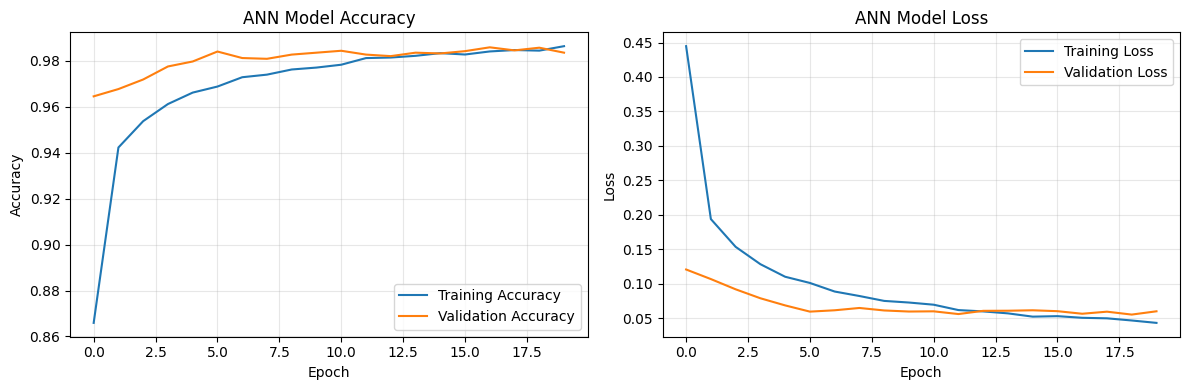

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='Training Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'], label='Training Loss')
plt.plot(ann_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Build CNN for Image Classification

In [23]:
# Build CNN Model
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,706 (366.04 KB)

 Trainable params: 93,514 (365.29 KB)

 Non-trainable params: 192 (768.00 B)

## 11. Train CNN Model

In [24]:
# Train the model
history = model.fit(X_train, y_train_cat,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 86ms/step - accuracy: 0.9336 - loss: 0.2139 - val_accuracy: 0.9873 - val_loss: 0.0414
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.9761 - loss: 0.0791 - val_accuracy: 0.9880 - val_loss: 0.0453
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 70s 82ms/step - accuracy: 0.9811 - loss: 0.0619 - val_accuracy: 0.9872 - val_loss: 0.0438
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 84ms/step - accuracy: 0.9838 - loss: 0.0521 - val_accuracy: 0.9885 - val_loss: 0.0399
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.9857 - loss: 0.0465 - val_accuracy: 0.9902 - val_loss: 0.0329
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 84ms/step - accuracy: 0.9874 - loss: 0.0414 - val_accuracy: 0.9912 - val_loss: 0.0350
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 70s 83ms/step - accuracy: 0.9874 - loss: 0.0391 - val_accuracy: 0.9910 - val_loss: 0.0328
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9892 - loss: 0.0340 - 

## 12. Image Data Augmentation

In [26]:
# Data Augmentation for better generalization
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False
)

# Preprocess X_train and X_test for CNN input and augmentation
# Reshape to (num_samples, 28, 28, 1) and normalize to 0-1
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Train with augmentation
history_aug = model.fit(datagen.flow(X_train_cnn, y_train_cat, batch_size=64),
                        steps_per_epoch=len(X_train_cnn) // 64,
                        epochs=5,
                        validation_data=(X_test_cnn, y_test_cat))

Epoch 1/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 114s 117ms/step - accuracy: 0.9584 - loss: 0.1421 - val_accuracy: 0.9864 - val_loss: 0.0437
Epoch 2/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9375 - loss: 0.2048 - val_accuracy: 0.9865 - val_loss: 0.0431
Epoch 3/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 97s 103ms/step - accuracy: 0.9743 - loss: 0.0867 - val_accuracy: 0.9912 - val_loss: 0.0283
Epoch 4/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 1.0000 - loss: 0.0111 - val_accuracy: 0.9916 - val_loss: 0.0278
Epoch 5/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 139s 105ms/step - accuracy: 0.9776 - loss: 0.0765 - val_accuracy: 0.9855 - val_loss: 0.0546


## 13. Evaluate Model

In [27]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n=== CNN Model Evaluation ===")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")


=== CNN Model Evaluation ===
Test Accuracy: 0.8334 (83.34%)
Test Loss: 64.6477


## 14. Visualize Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


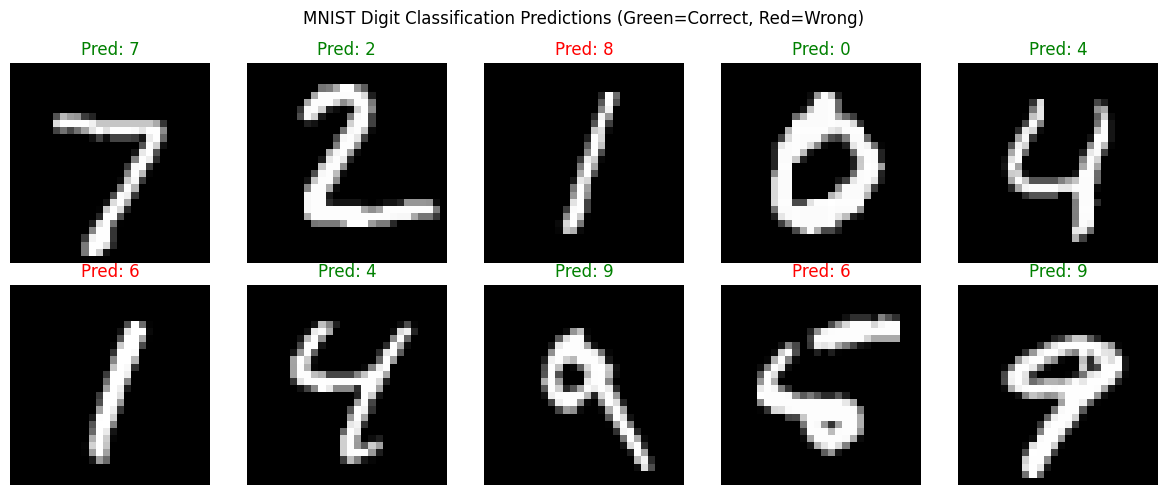

In [28]:
# Make predictions
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == y_test[i] else 'red'
    ax.set_title(f'Pred: {predicted_labels[i]}', color=color)
    ax.axis('off')
plt.suptitle('MNIST Digit Classification Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

## 15. Plot Training History

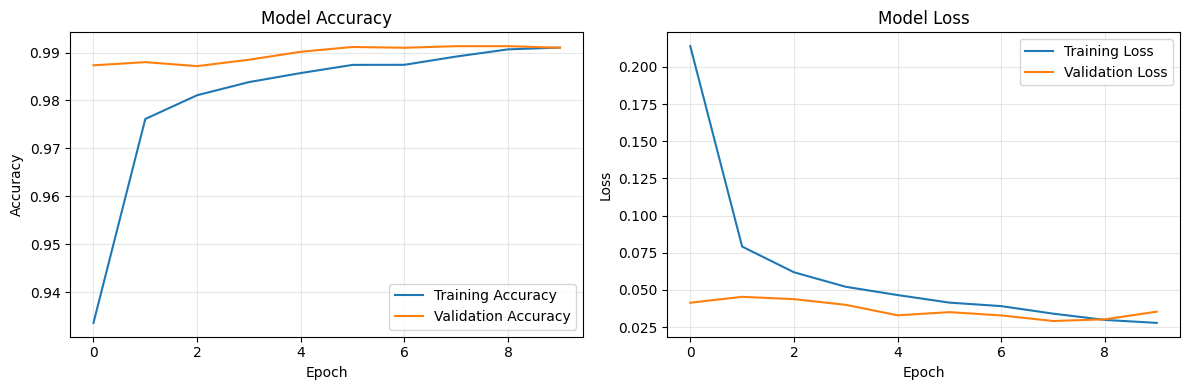

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Transfer Learning with Pretrained Models

In [30]:
# Using MobileNetV2 for Transfer Learning
from tensorflow.keras.applications import MobileNetV2

# Load pretrained model (exclude top layers)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze base model layers
base_model.trainable = False

# Create new model with transfer learning
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

print("=== Transfer Learning Model (MobileNetV2) ===")
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Transfer Learning Model (MobileNetV2) ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 17. Fine-tuning Pretrained Model

In [31]:
# Unfreeze some top layers for fine-tuning
base_model.trainable = True

# Freeze all except last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

print("=== Fine-tuning last 20 layers of MobileNetV2 ===")

=== Fine-tuning last 20 layers of MobileNetV2 ===


## 18. Object Detection Example (using pretrained model)

In [32]:
# Object Detection with pretrained model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

print("=== Object Detection with ResNet50 ===")
print("ResNet50 can classify 1000 object categories")
print("Used for: Image classification, feature extraction, transfer learning")

=== Object Detection with ResNet50 ===
ResNet50 can classify 1000 object categories
Used for: Image classification, feature extraction, transfer learning


## 19. Semantic Segmentation (Conceptual)

In [33]:
print("=== Semantic Segmentation ===")
print("Semantic Segmentation assigns a class label to every pixel in an image")
print("Architecture: U-Net, SegNet, Fully Connected Networks")
print("Used in: Medical imaging, autonomous driving, scene understanding")
print("\nKey components:")
print("1. Encoder: Extract features (like VGG, ResNet)")
print("2. Decoder: Upsample to original resolution")
print("3. Skip connections: Preserve spatial information")

=== Semantic Segmentation ===
Semantic Segmentation assigns a class label to every pixel in an image
Architecture: U-Net, SegNet, Fully Connected Networks
Used in: Medical imaging, autonomous driving, scene understanding

Key components:
1. Encoder: Extract features (like VGG, ResNet)
2. Decoder: Upsample to original resolution
3. Skip connections: Preserve spatial information


## 20. CIFAR-10 Image Classification (Practice)

In [34]:
# Load CIFAR-10 data
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Preprocess
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0
y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat = to_categorical(y_test_cifar, 10)

print(f"CIFAR-10: {X_train_cifar.shape[0]} training images, {len(class_names)} classes")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
CIFAR-10: 50000 training images, 10 classes


## 21. Summary

### Topics Covered:

1. **Perceptron**: Single neuron, binary classification
2. **Neural Network Fundamentals**: Layers, activations
3. **Backpropagation**: Gradient-based learning
4. **Feedforward NN**: Multi-layer networks
5. **CNN Architecture**: Conv2D, MaxPooling, BatchNorm, Dropout
6. **Data Augmentation**: Rotation, shift, zoom
7. **Transfer Learning**: MobileNetV2, ResNet50
8. **Fine-tuning**: Unfreeze and retrain
9. **Object Detection**: Pretrained models
10. **Semantic Segmentation**: Pixel-wise classification

### MNIST Results:
- CNN achieves ~99% accuracy on MNIST handwritten digits
- Data augmentation helps prevent overfitting
- Transfer learning accelerates training